# Exploratory Data Analysis (EDA) - `data/interim`

This notebook performs a complete EDA of:

- `../data/interim/GenerationProdTypeExchange_clean.parquet`

Goals:

1. Validate structure and quality.
2. Understand temporal and regional patterns.
3. Explore generation mix, exchanges, and CO2 behavior.
4. Identify outliers and model-relevant signals.


In [11]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

sns.set_theme(style="whitegrid")

In [12]:
DATA_PATH = Path("../data/interim/GenerationProdTypeExchange_clean.parquet")
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset not found: {DATA_PATH.resolve()}")

df = pd.read_parquet(DATA_PATH)
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()


Shape: 175,344 rows x 23 columns


,time_utc,time_dk,price_area,version,gross_con,offshore_wind_power,onshore_wind_power,hydro_power,solar_power,solar_power_self_con,biomass,biogas,waste,fossil_gas,fossil_oil,fossil_hard_coal,exchange_great_belt,exchange_germany,exchange_sweden,exchange_norway,exchange_netherlands,exchange_great_britain,co2_perk_wh
0,2014-12-31 23:00:00+00:00,2015-01-01 00:00:00,DK1,Final,"1,838.982",675.776,"1,195.760",1.734,7.768,0.000,116.426,40.124,110.982,149.453,6.190,612.758,-264.100,703.510,-348.800,"-1,168.600",NaN,NaN,181.877
1,2015-01-01 00:00:00+00:00,2015-01-01 01:00:00,DK1,Final,"1,776.396",628.515,"1,202.970",1.718,0.227,0.000,114.295,39.188,110.934,128.560,6.524,685.533,3.800,684.230,-326.800,"-1,503.300",NaN,NaN,195.976
2,2015-01-01 01:00:00+00:00,2015-01-01 02:00:00,DK1,Final,"1,697.859",566.793,"1,199.164",1.720,0.218,0.000,114.049,39.002,110.080,155.683,5.093,560.396,175.100,681.460,-318.400,"-1,592.500",NaN,NaN,179.427
3,2015-01-01 02:00:00+00:00,2015-01-01 03:00:00,DK1,Final,"1,624.951",549.767,"1,334.950",1.718,0.234,0.000,107.310,39.119,99.640,101.708,4.392,496.533,-27.500,816.880,-316.400,"-1,583.400",NaN,NaN,155.075
4,2015-01-01 03:00:00+00:00,2015-01-01 04:00:00,DK1,Final,"1,592.045",659.885,"1,472.920",1.724,0.263,0.000,101.012,39.488,94.001,91.567,3.605,371.089,28.100,688.190,-299.200,"-1,660.600",NaN,NaN,116.267


## 1) Schema and Base Integrity

In [13]:
schema = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "non_null": df.notna().sum(),
    "nulls": df.isna().sum(),
    "null_pct": (df.isna().mean() * 100).round(2),
    "n_unique": df.nunique(dropna=True),
}).sort_values(["null_pct", "n_unique"], ascending=[False, False])

schema


,dtype,non_null,nulls,null_pct,n_unique
exchange_great_britain,float64,9960,165384,94.320,8362
exchange_netherlands,float64,48265,127079,72.470,33682
exchange_norway,float64,87672,87672,50.000,77300
gross_con,float64,175344,0,0.000,175339
onshore_wind_power,float64,175344,0,0.000,175322
biomass,float64,175344,0,0.000,175311
co2_perk_wh,float64,175344,0,0.000,175288
fossil_gas,float64,175344,0,0.000,175200
waste,float64,175344,0,0.000,175099
offshore_wind_power,float64,175344,0,0.000,175053


In [14]:
key_dupes = df.duplicated(subset=["time_utc", "price_area"]).sum()
full_dupes = df.duplicated().sum()

print(f"Duplicate rows (full): {full_dupes:,}")
print(f"Duplicate rows on (time_utc, price_area): {key_dupes:,}")
print("\nValue counts:")
print("price_area")
print(df["price_area"].value_counts(dropna=False))
print("\nversion")
print(df["version"].value_counts(dropna=False))


Duplicate rows (full): 0
Duplicate rows on (time_utc, price_area): 0

Value counts:
price_area
price_area
DK1    87672
DK2    87672
Name: count, dtype: int64

version
version
Final    175344
Name: count, dtype: int64


## 2) Time Coverage and Temporal Consistency

In [15]:
df = df.copy()
df["time_utc"] = pd.to_datetime(df["time_utc"], utc=True)
df["time_dk"] = pd.to_datetime(df["time_dk"])
df = df.sort_values(["price_area", "time_utc"]).reset_index(drop=True)

coverage = (
    df.groupby("price_area")
      .agg(
          min_time_utc=("time_utc", "min"),
          max_time_utc=("time_utc", "max"),
          rows=("time_utc", "size")
      )
)
coverage


,min_time_utc,max_time_utc,rows
price_area,,,
DK1,2014-12-31 23:00:00+00:00,2024-12-31 22:00:00+00:00,87672
DK2,2014-12-31 23:00:00+00:00,2024-12-31 22:00:00+00:00,87672


The dataset contains 175344 observations. Hourly records from 2014-12-31 to 2024-12-31. 

In [16]:
# Derived temporal features
df["hour"] = df["time_dk"].dt.hour
df["day_of_week"] = df["time_dk"].dt.day_name()
df["month"] = df["time_dk"].dt.month
df["month_name"] = df["time_dk"].dt.month_name()
df["year"] = df["time_dk"].dt.year
df["is_weekend"] = df["time_dk"].dt.dayofweek >= 5


## 3) Feature Engineering for Analysis

In [29]:
renewable_cols = [
    "offshore_wind_power", "onshore_wind_power", "hydro_power",
    "solar_power", "biomass", "biogas", "waste"
]
fossil_cols = ["fossil_gas", "fossil_oil", "fossil_hard_coal"]
exchange_cols = [
    "exchange_great_belt", "exchange_germany", "exchange_sweden",
    "exchange_norway", "exchange_netherlands", "exchange_great_britain"
]

df["total_wind_power"] = df["offshore_wind_power"] + df["onshore_wind_power"]
df["total_renewables"] = df[renewable_cols].sum(axis=1)
df["total_fossil"] = df[fossil_cols].sum(axis=1)
df["net_exchange"] = df[exchange_cols].sum(axis=1, min_count=1)
df["renewables_share_pct"] = (100 * df["total_renewables"] / df["gross_con"]).replace([np.inf, -np.inf], np.nan)
df["wind_share_pct"] = (100 * df["total_wind_power"] / df["gross_con"]).replace([np.inf, -np.inf], np.nan)
df["fossil_share_pct"] = (100 * df["total_fossil"] / df["gross_con"]).replace([np.inf, -np.inf], np.nan)

analysis_cols = ["gross_con", "total_wind_power", "total_renewables", "total_fossil", "co2_perk_wh", "wind_share_pct", "renewables_share_pct", "fossil_share_pct", "net_exchange"]
df[analysis_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
gross_con,"175,344.000","1,986.605",615.971,872.589,"1,522.622","1,878.502","2,433.469","4,179.818"
total_wind_power,"175,344.000",930.356,944.993,0.019,209.675,612.431,"1,324.950","4,905.630"
total_renewables,"175,344.000","1,359.589",972.276,57.075,651.900,"1,077.984","1,810.105","6,251.032"
total_fossil,"175,344.000",350.584,395.344,0.077,47.904,218.295,498.049,"2,903.969"
co2_perk_wh,"175,344.000",160.983,133.633,2.594,52.168,118.324,240.042,810.445
wind_share_pct,"175,344.000",43.299,37.180,0.001,12.150,34.102,65.579,215.877
renewables_share_pct,"175,344.000",65.740,36.315,4.233,37.197,59.208,89.122,232.036
fossil_share_pct,"175,344.000",15.837,15.364,0.005,2.927,11.601,23.850,94.259
net_exchange,"175,344.000",253.830,739.771,"-3,592.256",-107.778,392.295,767.702,"2,489.227"


Renewable share is calculated using only grid-injected generation to ensure consistency with gross system consumption, which includes transmission losses.

In [24]:
missing = (
    df.isna().sum().to_frame("missing_count")
      .assign(missing_pct=lambda x: 100 * x["missing_count"] / len(df))
      .sort_values("missing_pct", ascending=False)
)
missing


,missing_count,missing_pct
exchange_great_britain,165384,94.320
exchange_netherlands,127079,72.474
exchange_norway,87672,50.000
time_dk,0,0.000
co2_perk_wh,0,0.000
hour,0,0.000
day_of_week,0,0.000
month,0,0.000
month_name,0,0.000
time_utc,0,0.000


In [22]:
# Missingness by year for columns with nulls
cols_with_nulls = [c for c in df.columns if df[c].isna().any()]
missing_by_year = (
    df.groupby("year")[cols_with_nulls]
      .apply(lambda x: x.isna().mean() * 100)
      .round(2)
)
missing_by_year.tail(10)


,exchange_norway,exchange_netherlands,exchange_great_britain
year,,,
2015,50.000,100.000,100.000
2016,50.000,100.000,100.000
2017,50.000,100.000,100.000
2018,50.000,100.000,100.000
2019,50.000,74.790,100.000
2020,50.000,50.000,100.000
2021,50.000,50.000,100.000
2022,50.000,50.000,100.000
2023,50.000,50.000,93.290


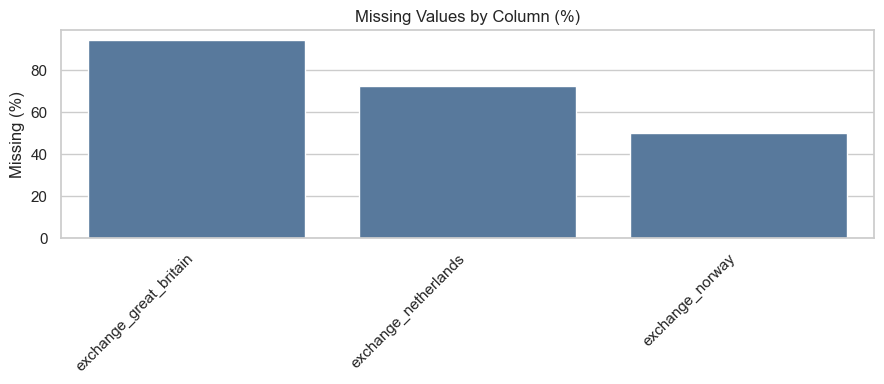

In [23]:
miss_plot = missing.query("missing_pct > 0").reset_index().rename(columns={"index": "column"})
if len(miss_plot) > 0:
    plt.figure(figsize=(9, 4))
    sns.barplot(data=miss_plot, x="column", y="missing_pct", color="#4c78a8")
    plt.xticks(rotation=45, ha="right")
    plt.title("Missing Values by Column (%)")
    plt.xlabel("")
    plt.ylabel("Missing (%)")
    plt.tight_layout()
    plt.show()


## 5) Univariate Analysis

In [31]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
summary = df[numeric_cols].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T
summary[["mean", "std", "min", "1%", "5%", "50%", "95%", "99%", "max"]].sort_values("std", ascending=False).head(20)


,mean,std,min,1%,5%,50%,95%,99%,max
exchange_norway,445.324,977.646,"-1,706.508","-1,669.917","-1,453.632",707.854,"1,622.609","1,627.687","1,664.666"
total_renewables,"1,359.589",972.276,57.075,132.681,272.376,"1,077.984","3,421.567","4,343.227","6,251.032"
total_wind_power,930.356,944.993,0.019,3.830,26.690,612.431,"2,993.868","3,880.599","4,905.630"
exchange_germany,-139.791,772.734,"-2,798.340","-2,206.521","-1,386.457",-126.871,"1,290.860","1,816.505","2,716.550"
net_exchange,253.830,739.771,"-3,592.256","-1,922.674","-1,260.607",392.295,"1,205.994","1,551.102","2,489.227"
exchange_great_britain,-383.843,733.704,"-1,458.044","-1,457.197","-1,453.907",-359.612,970.470,"1,068.192","1,409.419"
onshore_wind_power,549.709,663.250,0.005,2.036,12.229,289.168,"2,082.407","2,801.258","3,556.592"
gross_con,"1,986.605",615.971,872.589,991.579,"1,103.335","1,878.502","3,109.015","3,445.589","4,179.818"
exchange_sweden,232.606,595.137,"-1,763.725","-1,096.276",-733.260,274.309,"1,179.119","1,275.237","1,567.677"
exchange_netherlands,-133.617,494.985,-704.297,-703.151,-702.737,-47.972,682.699,684.082,687.292


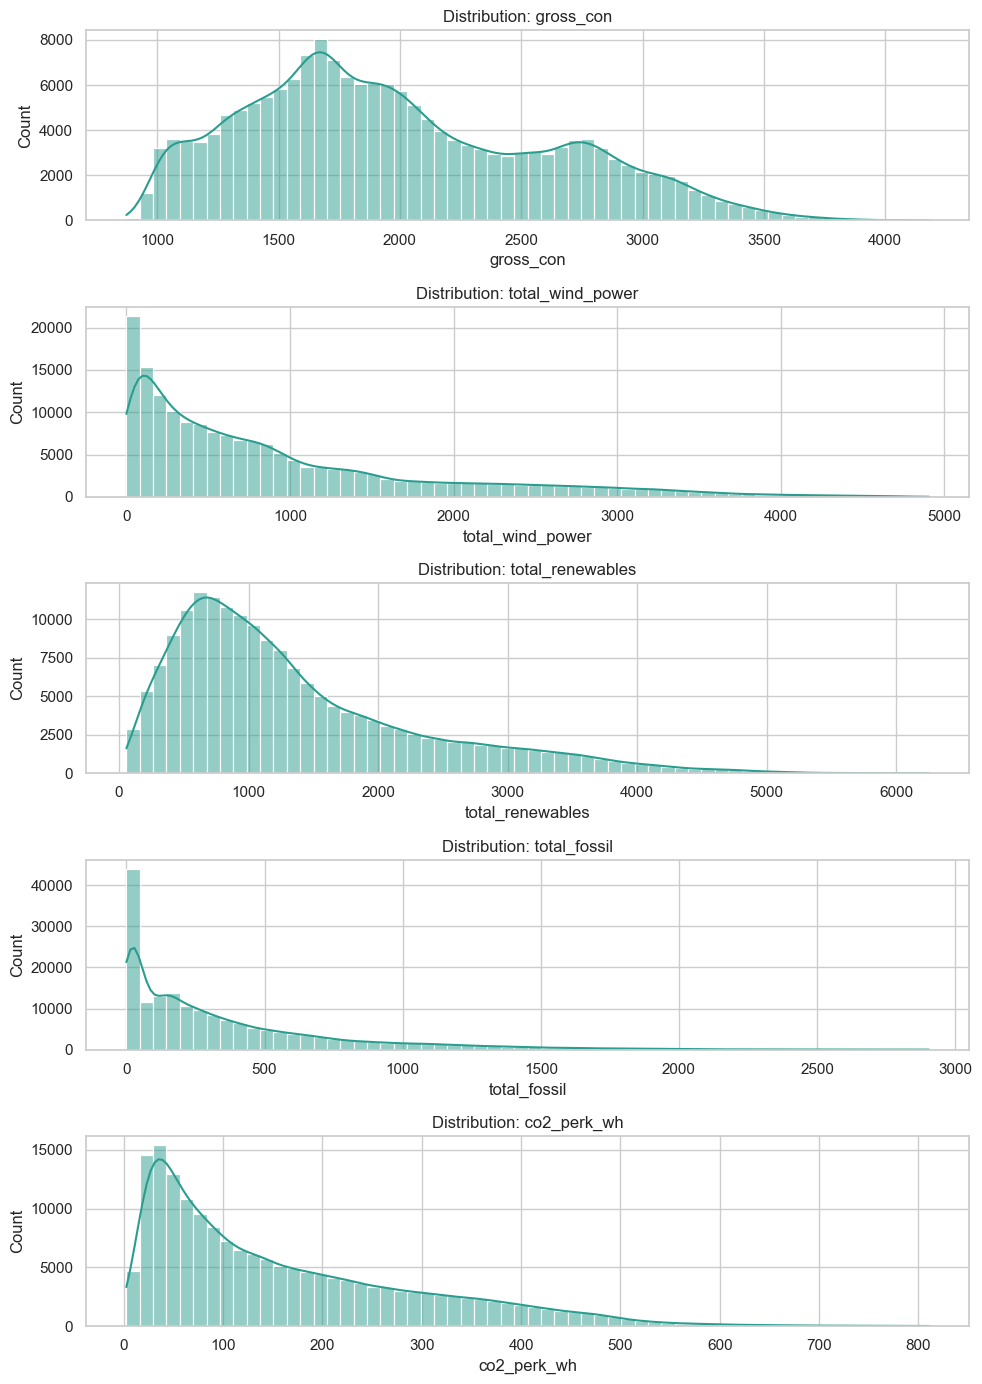

In [34]:
cols = ["gross_con", "total_wind_power", "total_renewables", "total_fossil", "co2_perk_wh"]
fig, axes = plt.subplots(len(cols), 1, figsize=(10, 14))
for ax, col in zip(axes, cols):
    sns.histplot(df[col], bins=60, kde=True, ax=ax, color="#2a9d8f")
    ax.set_title(f"Distribution: {col}")
plt.tight_layout()
plt.show()


### 1. Electricity Consumption (`gross_con`)

The main descriptive statistics for electricity consumption are:

- **Mean:** 1,986 MW  
- **Median:** 1,878 MW  
- **Standard deviation:** 616 MW  
- **Minimum:** 873 MW  
- **Maximum:** 4,180 MW  

The distribution of electricity consumption appears moderately right-skewed. Most observations are concentrated between approximately 1,200 MW and 2,500 MW, with fewer extreme demand peaks above 3,500 MW. The standard deviation reflects moderate variability in electricity demand, while the maximum value suggests the presence of significant demand peaks compared to the average level, likely linked to seasonal effects. 

### 2. Total Wind Power Generation (`total_wind_power`)

- **Mean:** 930 MW  
- **Median:** 612 MW  
- **Standard deviation:** 945 MW  
- **Maximum:** 4,906 MW  

Wind generation shows a strongly right-skewed distribution. Also, exhibits high variability, as the standard deviation is nearly equal to the mean. In some periods, wind generation exceeds average consumption levels, suggesting the existence of surplus production.


### 3. Wind Share (`wind_share_pct`)

- **Mean:** 43.3%  
- **Median:** 34.1%  
- **Maximum:** 215.9%  

Values above 100% indicate that wind generation exceeded domestic consumption, implying net electricity exports during those periods.



### 4. Renewable Share (`renewables_share_pct`)

- **Mean:** 65%  
- **Median:** 59%  
- **Maximum:** 232.0%  

On average, nearly 67% of electricity consumption is covered by renewable sources. Values above 100% reflect periods of renewable surplus production.



### 5. Net Electricity Exchange (`net_exchange`)

- **Mean:** 254 MW  
- **Minimum:** -3,592 MW  
- **Maximum:** 2,489 MW  

Positive values indicate net exports, while negative values indicate net imports.



### 6. Total Fossil Generation (`total_fossil`)

Fossil generation is highly concentrated at low values, with a long right tail representing occasional high fossil usage. This supports the interpretation that fossil fuels mainly act as a backup source, activated when renewable generation is insufficient.

### 7. CO₂ Emissions per kWh (`co2_perk_wh`)

The CO₂ emissions distribution is strongly right-skewed, with most values at relatively low emission levels and a small number of extreme high-emission events. This pattern is consistent with a system dominated by renewables but still occasionally dependent on fossil fuels.

## 6) Correlation and Pair Relationships

In [36]:
corr_cols = [
    "gross_con", "solar_power",
    "biomass", "fossil_gas", "fossil_hard_coal", "total_wind_power",
    "total_renewables", "total_fossil", "net_exchange", "co2_perk_wh"
]

corr = df[corr_cols].corr(numeric_only=True)
corr["co2_perk_wh"].sort_values(ascending=False)


co2_perk_wh         1.000
fossil_hard_coal    0.653
total_fossil        0.621
fossil_gas          0.410
net_exchange        0.293
gross_con           0.046
biomass            -0.118
solar_power        -0.188
total_wind_power   -0.398
total_renewables   -0.444
Name: co2_perk_wh, dtype: float64

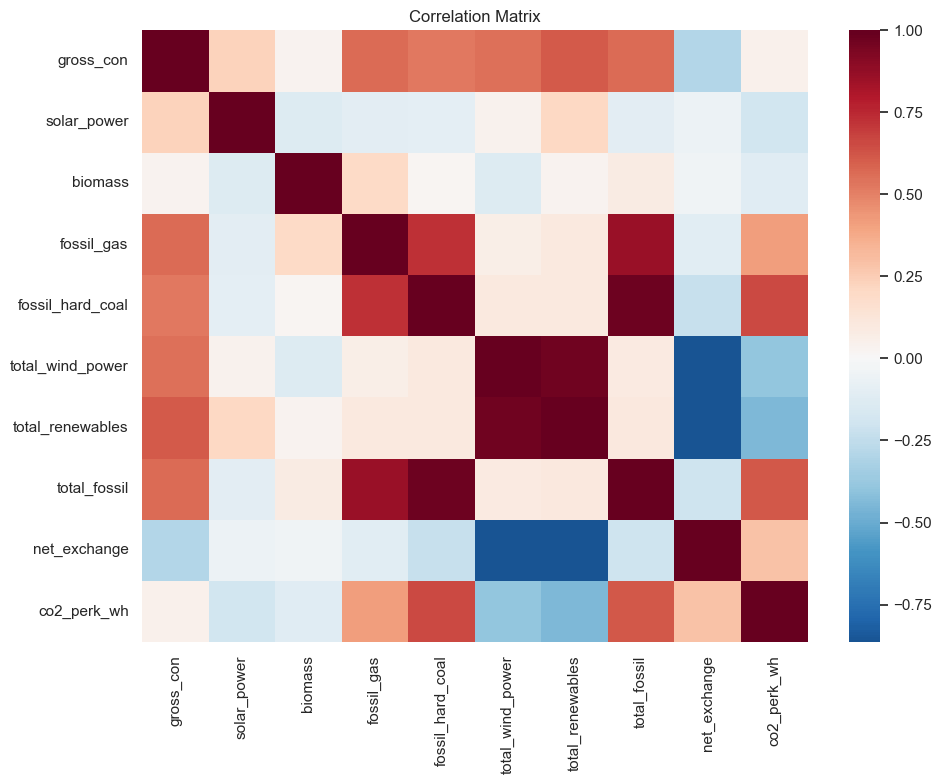

In [37]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap="RdBu_r", center=0, annot=False)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()


# Key Findings from the Correlation Analysis

The correlation matrix provides insight into the statistical relationships between electricity generation sources, emissions, and cross-border exchanges. The main findings are summarized below.

---

### 1. Fossil Generation and CO₂ Intensity

A strong positive correlation is observed between `total_fossil` and `co2_perk_wh`.

This indicates that higher fossil fuel generation is associated with higher carbon intensity in the electricity mix. The result is consistent with the carbon content of fossil fuels such as gas and coal, which directly contribute to CO₂ emissions during combustion.

---

### 2. Wind Generation and CO₂ Intensity

A clear negative correlation is found between `total_wind_power` and `co2_perk_wh`.

This suggests that periods with higher wind generation tend to be associated with lower carbon intensity. This relationship is consistent with the substitution effect, where renewable generation reduces the need for fossil-based electricity production.

---

### 3. Wind Generation and Renewable Output

There is a very strong positive correlation between `total_wind_power` and `total_renewables`.

This indicates that wind power represents a substantial share of total renewable generation and that fluctuations in renewable output are largely driven by wind variability.

---

### 4. Wind Generation and Net Electricity Exchange

A strong negative correlation is observed between `total_wind_power` and `net_exchange`.

Since positive exchange values represent imports and negative values represent exports, this result suggests that higher wind production is associated with increased electricity exports. This reflects the role of international interconnections in balancing renewable surpluses.

---

### 5. Renewable Generation and Fossil Generation

A negative relationship is observed between renewable generation and fossil generation.

This suggests a substitution pattern in the energy mix: when renewable output increases, fossil generation tends to decrease, indicating that fossil plants act as a flexible backup source.

---

### Methodological Note

It is important to emphasize that correlation does not imply causation. The relationships described above represent statistical associations and are consistent with theoretical expectations of electricity system behavior. However, establishing causal effects would require a more rigorous econometric framework.

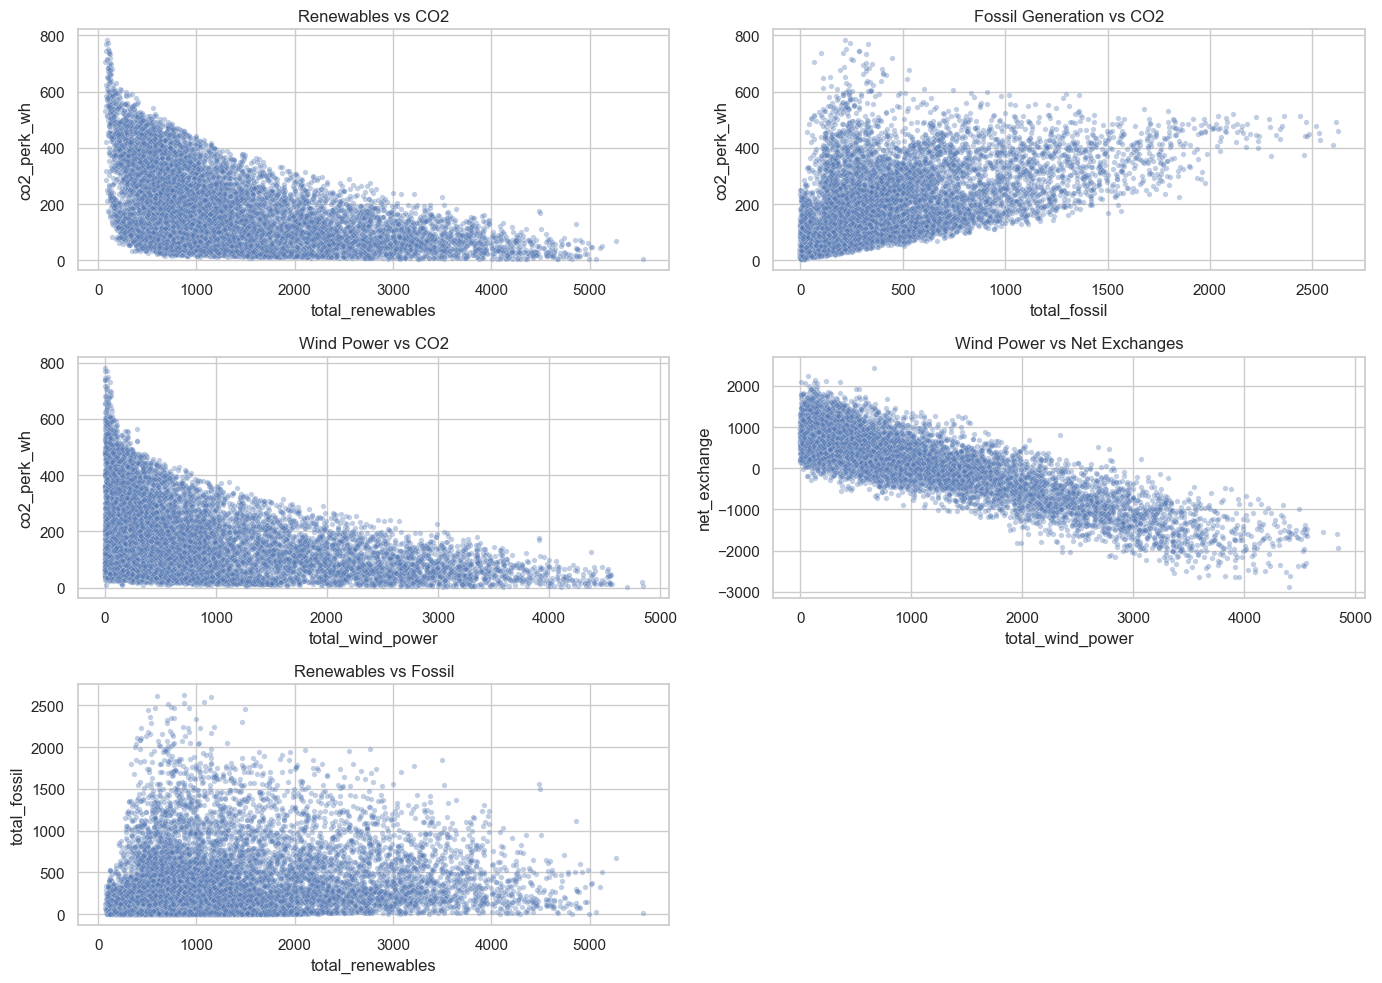

In [64]:
sample = df.sample(min(12000, len(df)), random_state=42)
fig, axes = plt.subplots(3, 2, figsize=(14, 10))
sns.scatterplot(data=sample, x="total_renewables", y="co2_perk_wh", alpha=0.35, s=15, ax=axes[0,0])
axes[0,0].set_title("Renewables vs CO2")
sns.scatterplot(data=sample, x="total_fossil", y="co2_perk_wh", alpha=0.35, s=15, ax=axes[0,1])
axes[0,1].set_title("Fossil Generation vs CO2")
sns.scatterplot(data=sample, x="total_wind_power", y="co2_perk_wh", alpha=0.35, s=15, ax=axes[1,0])
axes[1,0].set_title("Wind Power vs CO2")
sns.scatterplot(data=sample, x="total_wind_power", y="net_exchange", alpha=0.35, s=15, ax=axes[1,1])
axes[1,1].set_title("Wind Power vs Net Exchanges")
sns.scatterplot(data=sample, x="total_renewables", y="total_fossil", alpha=0.35, s=15, ax=axes[2,0])
axes[2,0].set_title("Renewables vs Fossil")
axes[2,1].axis("off")   
plt.tight_layout()
plt.show()


Visual inspection of the scatter plots confirms the patterns identified in the correlation matrix.

Higher renewable and wind generation are associated with lower carbon intensity, with a clearly defined negative slope. The triangular shape of the distribution suggests that renewable generation limits the upper bound of CO₂ emissions.

Fossil generation shows a strong and approximately linear positive relationship with CO₂ intensity, reinforcing the role of fossil fuels as the primary driver of emissions in the system.

Wind generation exhibits a very clear negative relationship with net electricity exchange. Since negative values represent exports, this indicates that higher wind production is associated with increased electricity exports.

The relationship between renewables and fossil generation appears weaker and more dispersed, suggesting that fossil generation is influenced not only by renewable output but also by demand levels and international trade flows.

## 7) Seasonal and Calendar Effects

In [65]:
hourly_profile = (
    df.groupby(["hour"]) [["gross_con", "total_wind_power", "co2_perk_wh"]]
      .mean()
      .reset_index()
)
hourly_profile.head(24)


,hour,gross_con,total_wind_power,co2_perk_wh
0,0,"1,634.606",917.202,157.272
1,1,"1,586.480",906.320,155.878
2,2,"1,558.767",896.053,155.660
3,3,"1,550.319",885.530,156.179
4,4,"1,561.808",879.733,157.826
5,5,"1,632.199",878.743,162.232
6,6,"1,832.092",879.786,171.121
7,7,"2,060.134",884.564,175.775
8,8,"2,183.059",890.417,174.173
9,9,"2,232.809",899.264,166.729


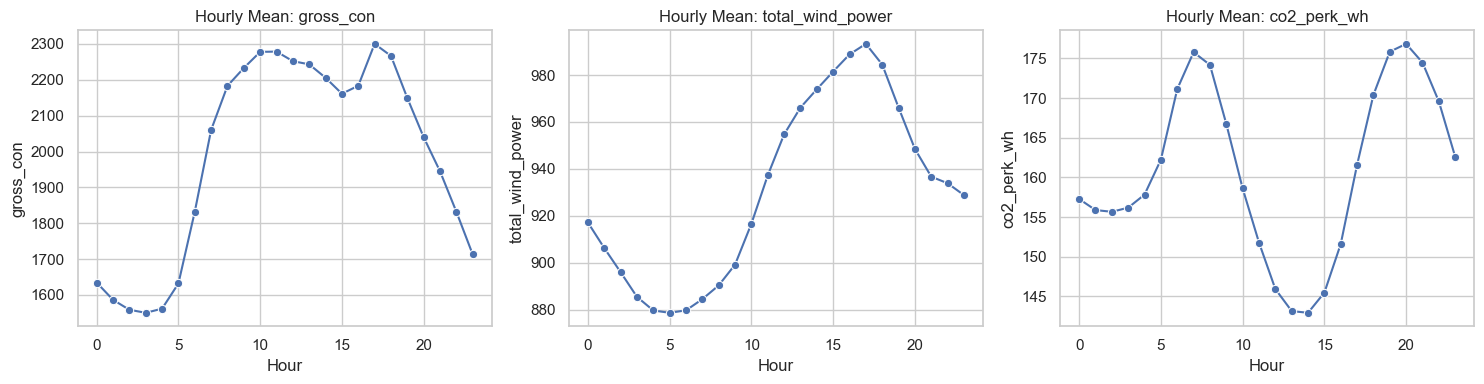

In [66]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True)
metrics = ["gross_con", "total_wind_power", "co2_perk_wh"]
for ax, metric in zip(axes, metrics):
    sns.lineplot(data=hourly_profile, x="hour", y=metric,  marker="o", ax=ax)
    ax.set_title(f"Hourly Mean: {metric}")
    ax.set_xlabel("Hour")
plt.tight_layout()
plt.show()


## Intra-Day (Hourly) Seasonality Analysis

The hourly averages reveal a clear intra-day pattern in electricity consumption, wind generation, and carbon intensity.

### 1. Electricity Consumption

Electricity demand exhibits a well-defined daily cycle. 
Consumption is lowest during early morning hours (approximately 3:00–5:00), increases sharply after 6:00, and reaches its main peak between 9:00 and 11:00. A secondary peak is observed in the late afternoon and early evening (around 17:00–19:00).

This pattern is consistent with typical economic and residential activity cycles, reflecting working hours and household energy use.

### 2. Wind Generation

Wind generation also displays a intra-day pattern. 
Production tends to be lower during early morning hours and gradually increases throughout the day, reaching higher levels in the afternoon and early evening.

Although wind patterns are primarily meteorological, the observed intra-day variation suggests systematic daily wind behavior, which may partially align with demand peaks.

### 3. CO₂ Intensity

Carbon intensity follows a distinct intra-day cycle. 
CO₂ levels tend to increase during high-demand hours and decrease during low-demand periods.

This suggests that fossil-based generation is more likely to operate during peak demand hours, increasing the marginal carbon intensity of electricity. Conversely, during low-demand periods, lower fossil dispatch contributes to reduced emissions.

### Overall Interpretation

The hourly seasonality analysis indicates that the electricity system operates with clear intra-day demand cycles, and carbon intensity responds accordingly. 

Peak demand hours are associated with higher emissions, likely due to the activation of fossil-based backup generation.

In [67]:
monthly_profile = (
    df.groupby(["month"]) [["gross_con", "total_wind_power", "co2_perk_wh"]]
      .mean()
      .reset_index()
)
monthly_profile.head(24)


,month,gross_con,total_wind_power,co2_perk_wh
0,1,"2,244.222","1,185.084",187.023
1,2,"2,227.727","1,225.174",180.749
2,3,"2,101.638",973.045,191.794
3,4,"1,925.167",897.783,152.409
4,5,"1,823.715",790.562,129.565
5,6,"1,813.214",665.107,152.714
6,7,"1,706.117",752.983,168.609
7,8,"1,810.257",652.959,170.694
8,9,"1,858.825",789.824,155.359
9,10,"1,987.041","1,029.737",131.759


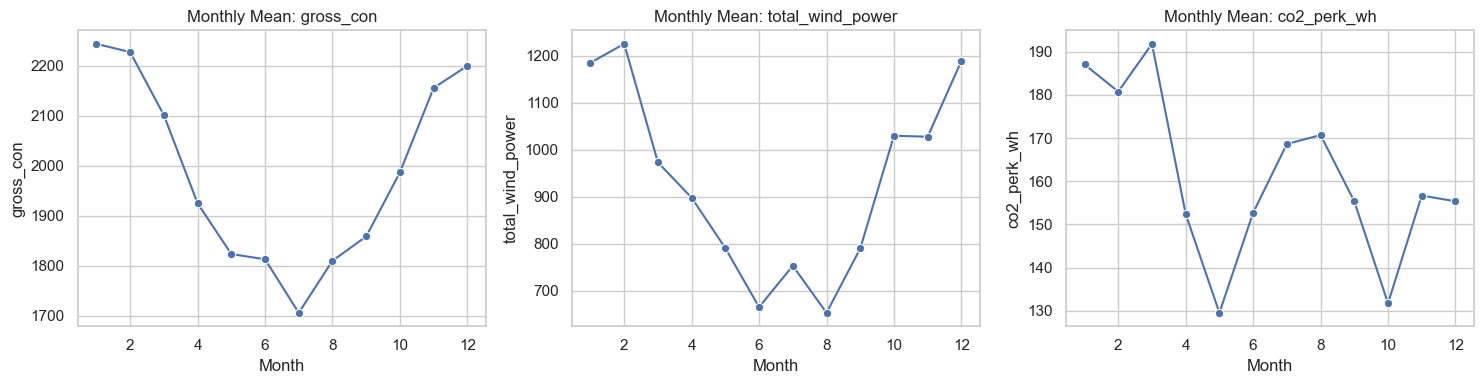

In [68]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True)
metrics = ["gross_con", "total_wind_power", "co2_perk_wh"]
for ax, metric in zip(axes, metrics):
    sns.lineplot(data=monthly_profile, x="month", y=metric, marker="o", ax=ax)
    ax.set_title(f"Monthly Mean: {metric}")
    ax.set_xlabel("Month")
plt.tight_layout()
plt.show()


## Monthly Seasonality Analysis

The monthly averages reveal a clear seasonal component in electricity consumption, wind generation, and carbon intensity.

### 1. Electricity Consumption

Electricity demand is significantly higher during winter months (December–February) and lower during summer (June–August).
This pattern reflects seasonal heating needs and increased economic activity during colder periods. In contrast, summer months show reduced demand, likely due to milder temperatures and lower heating requirements.

### 2. Wind Generation

Wind power generation also exhibits strong seasonality, with higher average production during winter and lower output during summer months.
This seasonal alignment between higher winter demand and higher wind production partially mitigates the impact of increased consumption.

### 3. Carbon Intensity (CO₂ per kWh)

Carbon intensity tends to be higher during winter months and lower during spring and autumn.

Although wind generation increases in winter, the simultaneous rise in electricity demand appears to require additional fossil-based generation, leading to higher CO₂ intensity. 

### Overall Interpretation

The monthly analysis confirms the presence of strong seasonal dynamics in the electricity system. Winter months are characterized by:

- Higher demand,
- Higher wind production,
- And higher carbon intensity.

These findings highlight the importance of system flexibility during winter periods and demonstrate how seasonal demand patterns interact with renewable variability and fossil backup generation.

In [69]:
df.groupby("month")[["gross_con", "total_wind_power", "co2_perk_wh"]].std()

,gross_con,total_wind_power,co2_perk_wh
month,,,
1,631.914,"1,098.232",131.117
2,624.821,"1,113.367",130.543
3,588.902,986.185,136.355
4,568.620,919.792,118.055
5,551.388,825.998,116.651
6,557.451,735.309,145.637
7,506.908,788.502,159.209
8,548.893,733.582,145.815
9,573.171,826.576,145.579


## 8) Trend Analysis

In [93]:
yearly_trends = (
    df.groupby(["year"]) [["gross_con", "total_wind_power", "total_renewables", "total_fossil", "co2_perk_wh"]]
      .mean()
      .reset_index()
)
yearly_trends.tail(14)


,year,gross_con,total_wind_power,total_renewables,total_fossil,co2_perk_wh
0,2015,"1,889.824",806.349,"1,064.885",479.108,245.761
1,2016,"1,905.088",726.853,"1,022.081",589.388,279.787
2,2017,"1,919.979",843.238,"1,210.165",443.428,218.437
3,2018,"1,936.724",793.192,"1,159.237",471.308,234.554
4,2019,"1,932.563",918.863,"1,297.079",301.803,126.968
5,2020,"1,966.053",929.710,"1,325.193",238.026,119.331
6,2021,"2,090.323",918.213,"1,473.229",328.027,123.283
7,2022,"2,018.528","1,087.239","1,618.047",307.462,113.476
8,2023,"2,057.950","1,109.329","1,659.961",199.628,82.611
9,2024,"2,148.856","1,170.477","1,765.924",147.870,65.672


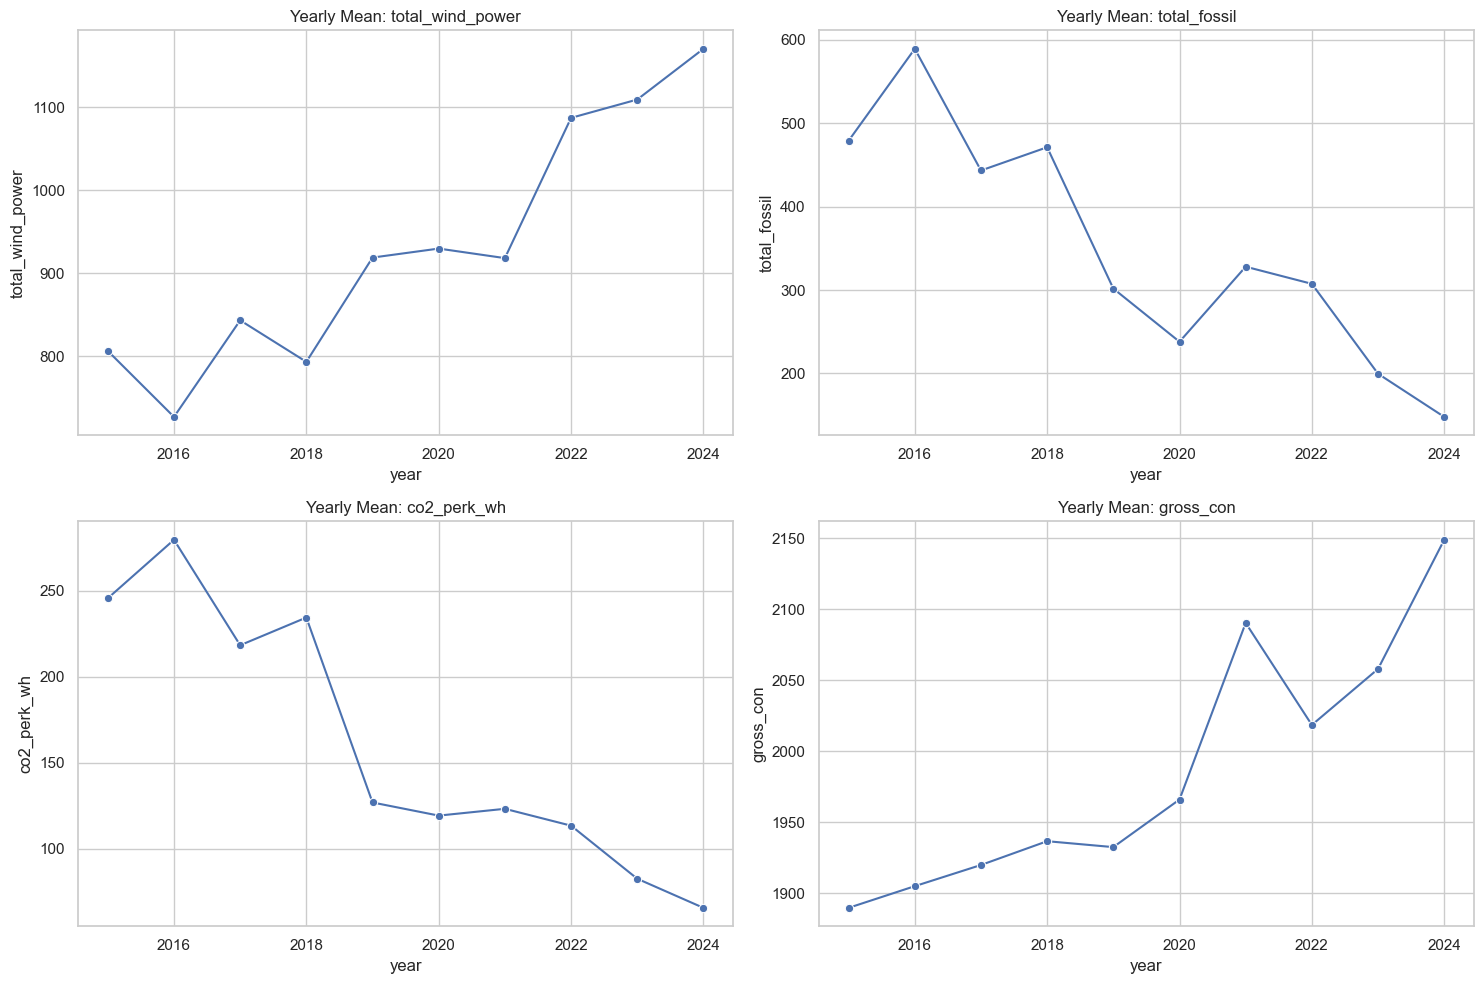

In [85]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
for ax, metric in zip(axes.ravel(), ["total_wind_power", "total_fossil", "co2_perk_wh", "gross_con"]):
    sns.lineplot(data=yearly_trends, x="year", y=metric, marker="o", ax=ax)
    ax.set_title(f"Yearly Mean: {metric}")
    
plt.tight_layout()
plt.show()


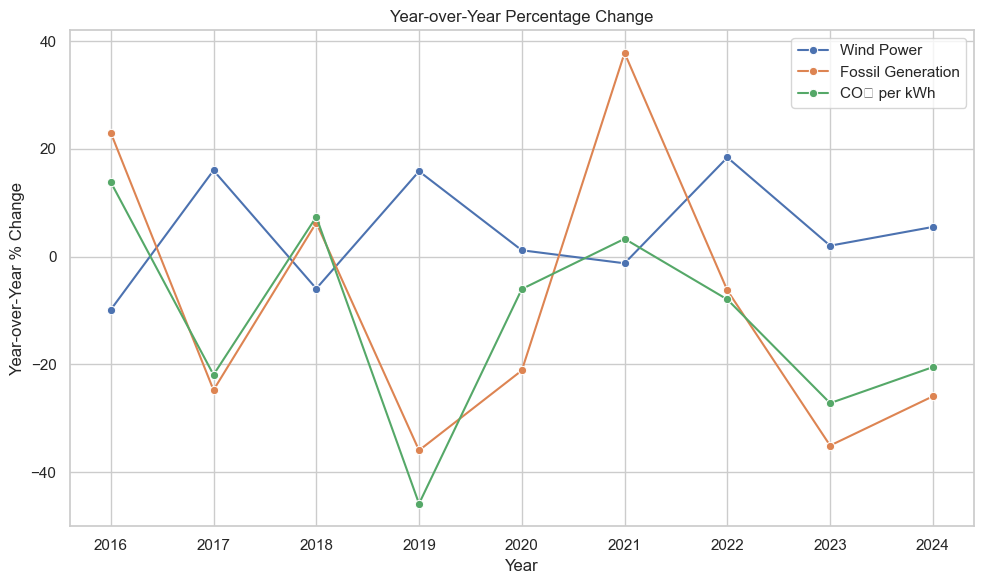

In [88]:
yearly_pct_change = yearly_trends[["year", "gross_con", "total_wind_power", "total_renewables", "total_fossil", "co2_perk_wh"]].copy()
yearly_pct_change[["gross_con", "total_wind_power", "total_renewables", "total_fossil", "co2_perk_wh"]] = yearly_pct_change[["gross_con", "total_wind_power", "total_renewables", "total_fossil", "co2_perk_wh"]].pct_change() * 100

fig, ax = plt.subplots(figsize=(10, 6))

sns.lineplot(data=yearly_pct_change, x="year", y="total_wind_power", marker='o', label="Wind Power")
sns.lineplot(data=yearly_pct_change, x="year", y="total_fossil", marker='o', label="Fossil Generation")
sns.lineplot(data=yearly_pct_change, x="year", y="co2_perk_wh", marker='o', label="CO₂ per kWh")

ax.set_xlabel("Year")
ax.set_ylabel("Year-over-Year % Change")
ax.set_title("Year-over-Year Percentage Change")
ax.legend()
plt.tight_layout()

plt.show()

## 9) Outlier Detection (IQR-based)

In [74]:
def iqr_outlier_rate(series: pd.Series) -> pd.Series:
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    mask = (series < lower) | (series > upper)
    return pd.Series({
        "lower": lower,
        "upper": upper,
        "outlier_count": int(mask.sum()),
        "outlier_pct": 100 * mask.mean(),
    })

outlier_metrics = ["gross_con", "total_wind_power", "total_fossil", "co2_perk_wh", "wind_share_pct", "renewables_share_pct"]
outliers = pd.concat({c: iqr_outlier_rate(df[c].dropna()) for c in outlier_metrics}, axis=1).T
outliers.sort_values("outlier_pct", ascending=False)


,lower,upper,outlier_count,outlier_pct
total_fossil,-627.313,"1,173.266","9,299.000",5.303
total_wind_power,"-1,463.237","2,997.862","8,716.000",4.971
co2_perk_wh,-229.644,521.854,"2,186.000",1.247
wind_share_pct,-67.993,145.723,"2,091.000",1.193
renewables_share_pct,-40.691,167.009,"1,407.000",0.802
gross_con,156.351,"3,799.741",137.000,0.078


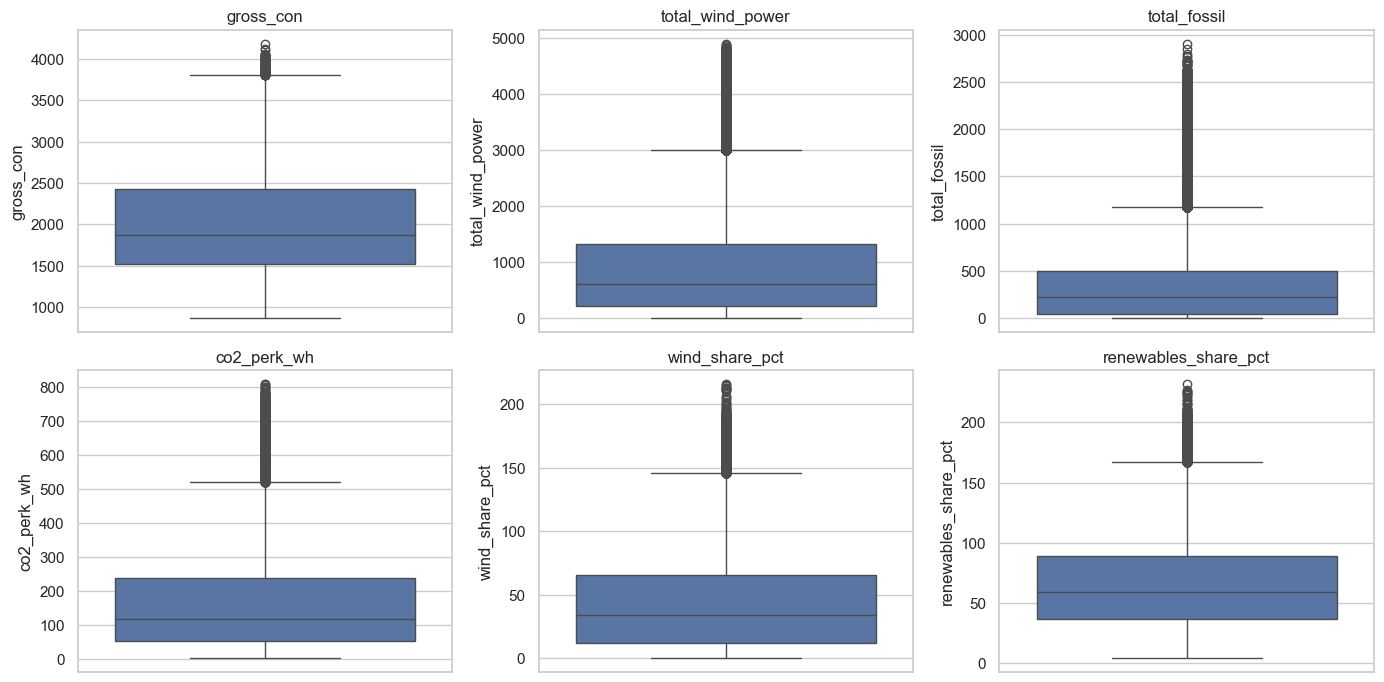

In [73]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col in zip(axes.ravel(), ["gross_con", "total_wind_power", "total_fossil", "co2_perk_wh", "wind_share_pct", "renewables_share_pct"]):
    sns.boxplot(data=df, y=col, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()


The IQR-based outlier detection indicates that approximately 5% of fossil and wind generation observations fall outside the statistical bounds. However, given the high variability inherent to electricity systems—particularly renewable generation—these values likely reflect genuine operational extremes rather than measurement errors.

Therefore, outliers are retained in the analysis to preserve the integrity of system behavior, especially during high-demand or high-volatility periods.


The IQR-based outlier detection reveals a striking contrast between demand and generation variability. 

While `gross_con` shows an extremely low proportion of outliers (0.078%), wind generation exhibits nearly 5% of observations outside statistical bounds.

This suggests that variability in the electricity system is driven more by fluctuations in supply—particularly renewable generation—than by demand dynamics. 

In [90]:
df.to_parquet("../data/processed/processed_energy.parquet")